#### Project Overview:
**- Task:** predict the fuel efficiency of a car in miles per gallon (mpg).

**- Train dataset:** https://archive.ics.uci.edu/ml/datasets/auto+mpg

**- Feature types:** mixed continuous numeric features, nominal categorical features and ordial features

**- Output:** predicted mpg values (continuous numeric value)

**- Pipeline:**\
(1) data setup\
(2) data analysis\
(3) data preprocessing: drop nan, scaling\
(4) train the model\
(5) evaluate the model

In [132]:
# import libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import seaborn as sns

##### 1. Data Setup

In [133]:
# follow the download instruction on https://archive.ics.uci.edu/ml/datasets/auto+mpg
# fetch dataset
auto_mpg = fetch_ucirepo(id=9)

# data
X = auto_mpg.data.features
y = auto_mpg.data.targets

# metadata
print(auto_mpg.metadata)

# variables
print(auto_mpg.variables)

{'uci_id': 9, 'name': 'Auto MPG', 'repository_url': 'https://archive.ics.uci.edu/dataset/9/auto+mpg', 'data_url': 'https://archive.ics.uci.edu/static/public/9/data.csv', 'abstract': 'Revised from CMU StatLib library, data concerns city-cycle fuel consumption', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 398, 'num_features': 7, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['mpg'], 'index_col': ['car_name'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1993, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5859H', 'creators': ['R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for th

In [134]:
# concatenate X, y for analysis
df = pd.concat([X, y], axis=1)
print(df.columns)

Index(['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration',
       'model_year', 'origin', 'mpg'],
      dtype='object')


##### 2. Data Analysis

In [135]:
# Sample overview
df.head()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.0,8,130.0,3504,12.0,70,1,18.0
1,350.0,8,165.0,3693,11.5,70,1,15.0
2,318.0,8,150.0,3436,11.0,70,1,18.0
3,304.0,8,150.0,3433,12.0,70,1,16.0
4,302.0,8,140.0,3449,10.5,70,1,17.0


In [136]:
# check column info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
 7   mpg           398 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 25.0 KB


In [137]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
horsepower,392.0,104.469388,38.491160,46.0,75.000,93.5,126.000,230.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
model_year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
origin,398.0,1.572864,0.802055,1.0,1.000,1.0,2.000,3.0
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6


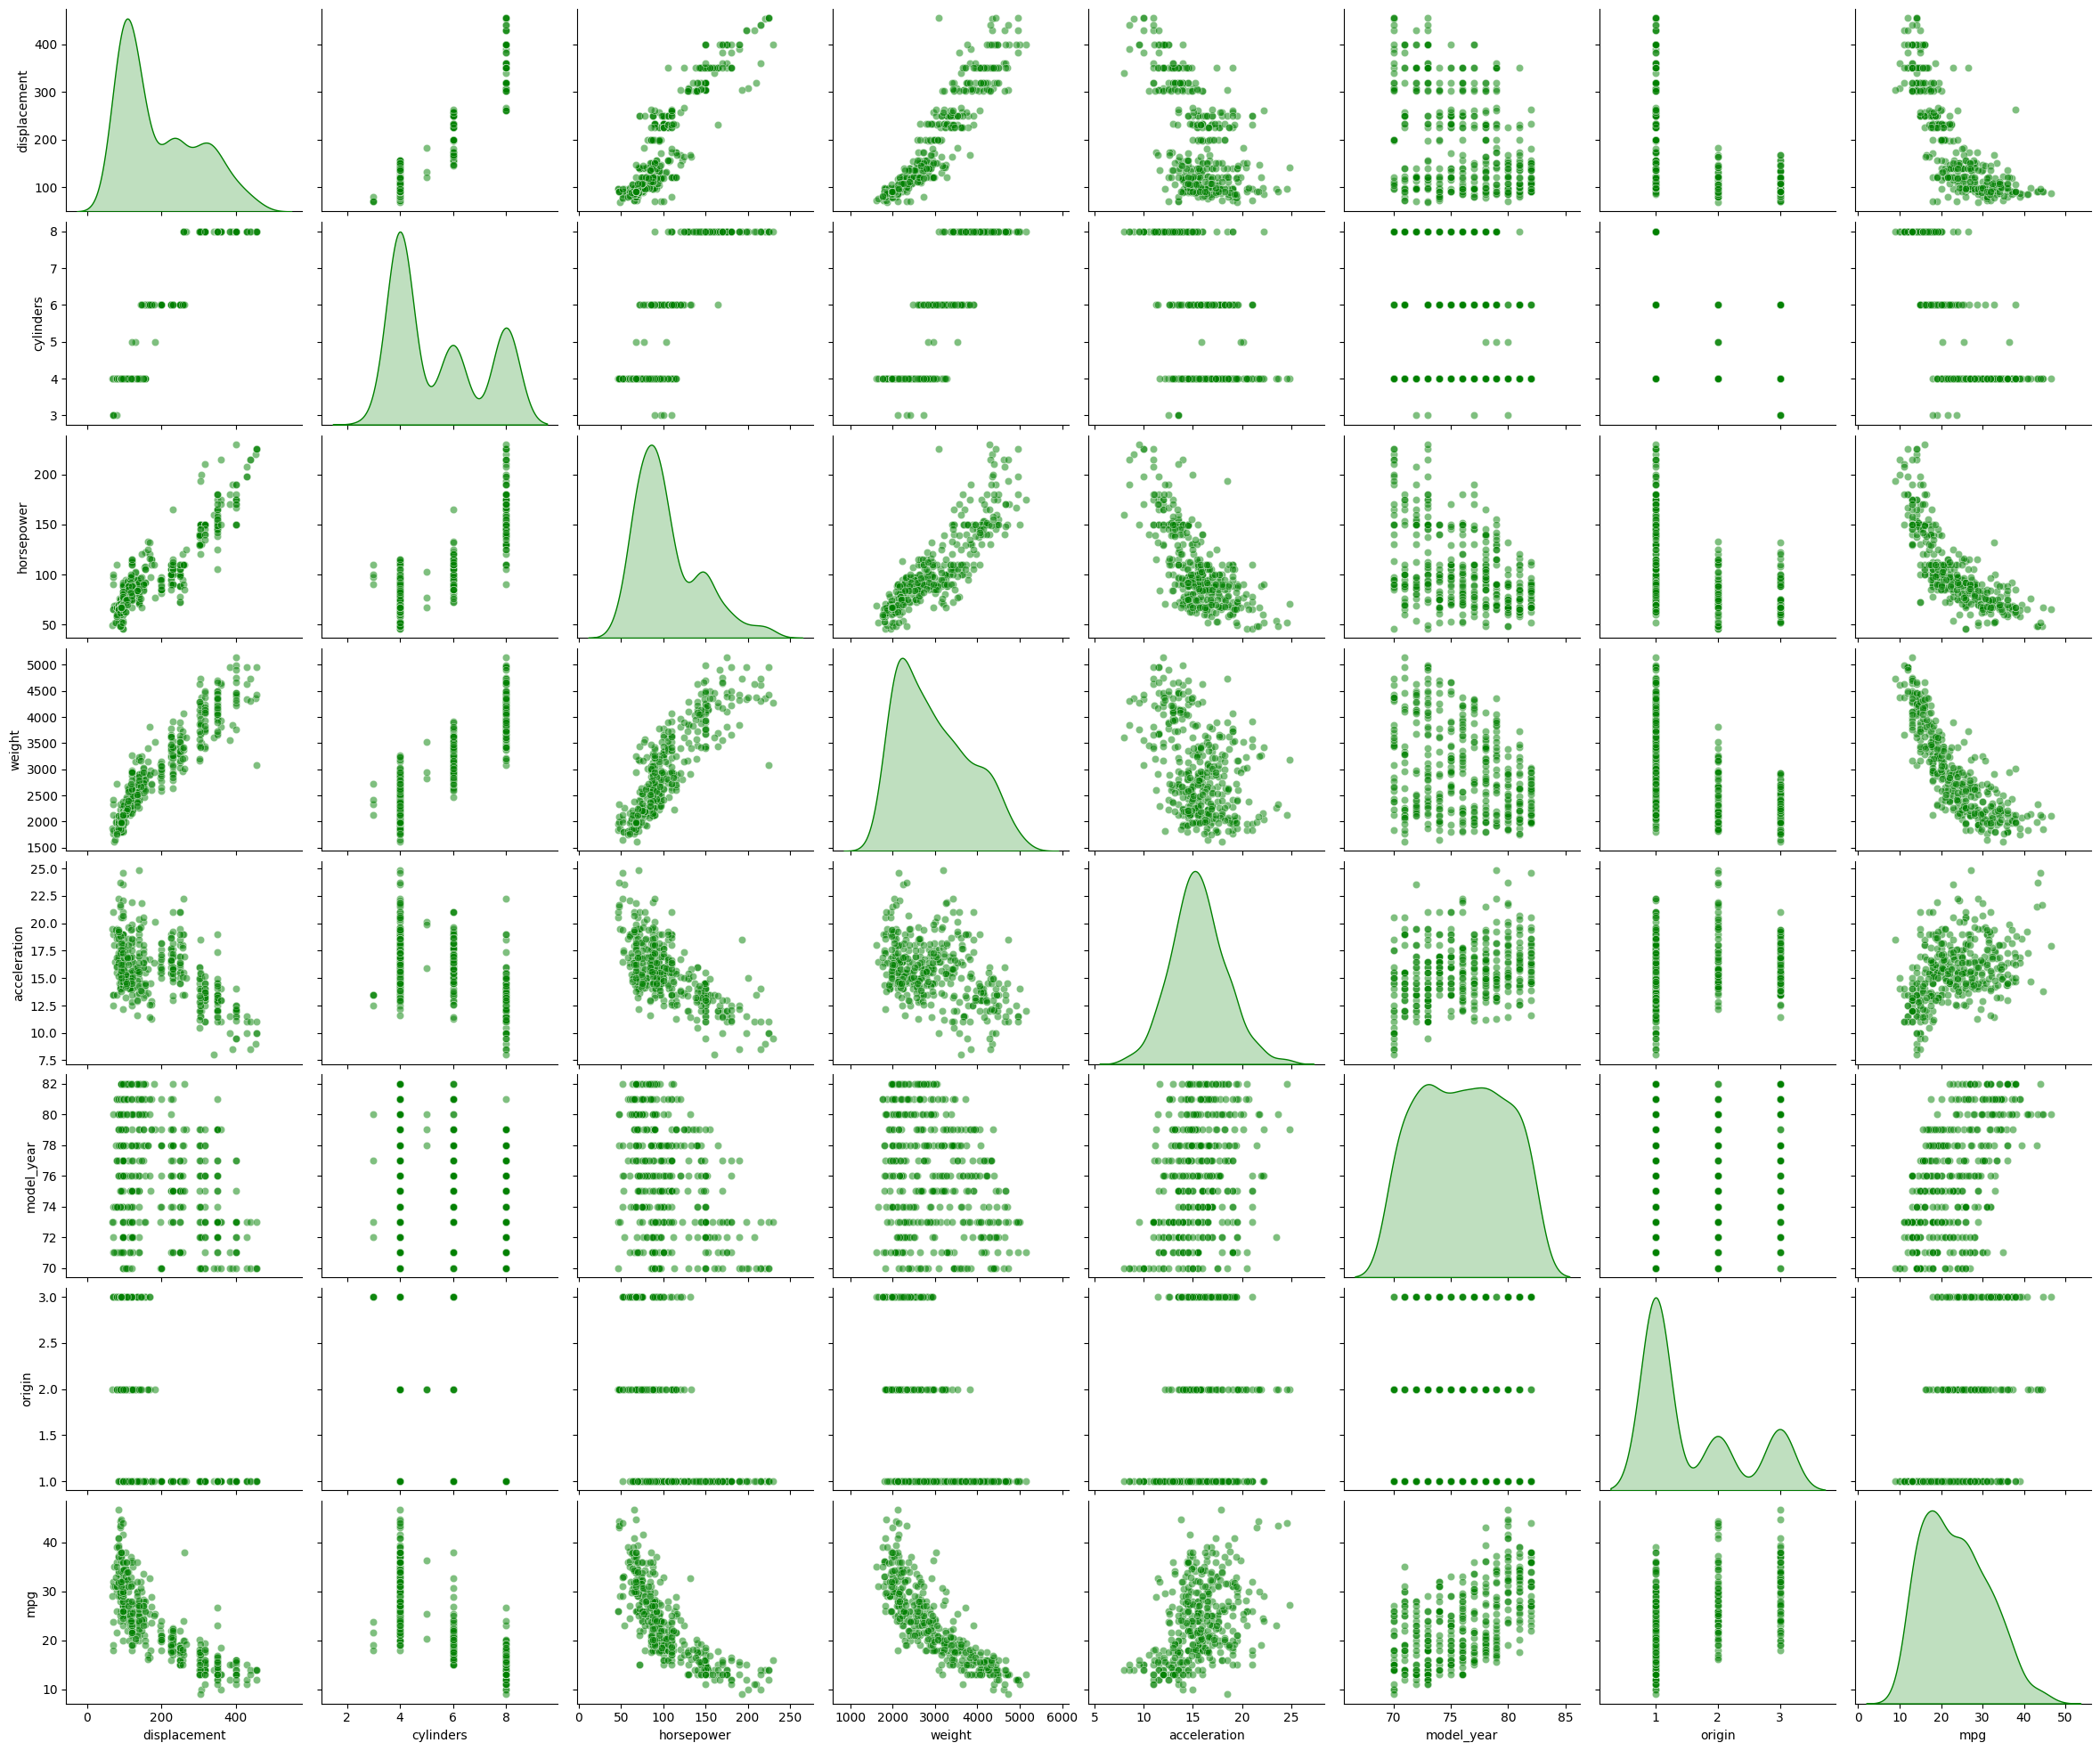

In [138]:
sns.pairplot(df, plot_kws={'alpha':0.5, 'color': 'green'}, 
             diag_kind="kde", diag_kws={'color': 'green'},
             height=2.5, aspect=1.2)

##### 3. Data Preprocessing
(i) drop na rorws

(ii) pipeline:
- nominal categorical feature: origin -> one hot encoding
- continous numeric features -> standard scaler
- discrete numeric features: cylinders, mode_years -> standard scaler

**(i) drop na rows**

In [139]:
# drop na rows
df.dropna(inplace=True)
df = df.reset_index(drop=True)

In [140]:
# check missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        392 non-null    int64  
 4   acceleration  392 non-null    float64
 5   model_year    392 non-null    int64  
 6   origin        392 non-null    int64  
 7   mpg           392 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 24.6 KB


**(ii) pipeline**

In [141]:
# split the data
df_train, df_test = train_test_split(df, train_size=0.8, random_state=1)

In [142]:
# separate features and target
target = ['mpg']
features = df.columns.difference(target).to_list()
X_train, y_train = df_train[features], df_train[target].values
X_test, y_test = df_test[features], df_test[target].values

# separate features
nominal_features = ['origin']
numeric_features = df.columns.difference(nominal_features).to_list()

print(f"{target = }")
print(f"{nominal_features = }")
print(f"{numeric_features = }")

target = ['mpg']
nominal_features = ['origin']
numeric_features = ['acceleration', 'cylinders', 'displacement', 'horsepower', 'model_year', 'mpg', 'weight']


In [143]:
preprocessor = ColumnTransformer(transformers=[
    ('numeric', StandardScaler(), numeric_features),
    ('nominal', OneHotEncoder(handle_unknown='ignore'), nominal_features)
], n_jobs=2)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('nominal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",2
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

In [144]:
# data transformation
X_train_transformed = preprocessor.fit_transform(df_train)
X_test_transformed = preprocessor.transform(df_test)

In [145]:
# convert numpy data to tensor
X_train_transformed_tensor = torch.tensor(X_train_transformed).float()
X_test_transformed_tensor = torch.tensor(X_test_transformed).float()
y_train_tensor = torch.tensor(y_train).float()
y_test_tensor = torch.tensor(y_test).float()

In [146]:
X_train_transformed_tensor.dtype, y_train_tensor.dtype

(torch.float32, torch.float32)

In [147]:
X_train_transformed_tensor.shape

torch.Size([313, 10])

In [148]:
# create a Dataset and Data Loader
train_ds = TensorDataset(X_train_transformed_tensor, y_train_tensor)
batch_size = 4
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

##### 4. Train the Model

In [149]:
# create a model:
feature_size = X_train_transformed_tensor.shape[1]
input_size = feature_size
output_size = 1
# hidden_units = [16, 8, 4]
hidden_units = [8, 4]

all_layers = []
for hidden_unit in hidden_units:
    all_layers.append(nn.Linear(input_size, hidden_unit))
    all_layers.append(nn.ReLU())
    input_size = hidden_unit
all_layers.append(nn.Linear(input_size, output_size))

model = nn.Sequential(*all_layers)
model

Sequential(
  (0): Linear(in_features=10, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=1, bias=True)
)

In [150]:
# declare loss and optimizer
loss_fn = nn.MSELoss(reduce="mean")

learning_rate = 1e-3
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)

/home/vinhn/bigdrive/course-repository/general-env/lib/python3.12/site-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='mean' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


In [151]:
# train the model
torch.manual_seed(1)

n_epochs = 10
loss_hist = []

for epoch in range(n_epochs):
    epoch_loss = 0
    for x_batch, y_batch in train_dl:
        y_pred = model.forward(x_batch)

        loss = loss_fn(y_pred, y_batch)
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item() * len(y_batch)

    loss_hist.append(epoch_loss / len(train_dl.dataset))

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch + 1} - Loss: ", epoch_loss / len(train_dl.dataset))

Epoch 10 - Loss:  0.37955807161312133


##### 5. Evaluate the model

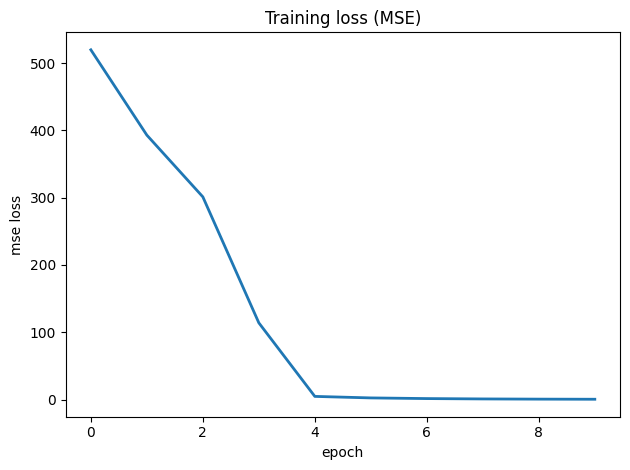

In [152]:
# training loss
plt.plot(loss_hist, lw=2)
plt.title("Training loss (MSE)")
plt.xlabel("epoch")
plt.ylabel("mse loss")
plt.tight_layout()
plt.show()

In [153]:
# evaluate model on test set
with torch.no_grad():
    test_preds = model(X_test_transformed_tensor)
    mse_loss = loss_fn(test_preds, y_test_tensor).item() 
    mae_loss = nn.L1Loss()(test_preds, y_test_tensor).item()
    print(f"{mse_loss = }")
    print(f"{mae_loss = }")

mse_loss = 0.2783001959323883
mae_loss = 0.4105357825756073


In [154]:
# evaluate on the first 5 samples
for i, (p, t)in enumerate(zip(test_preds, y_test_tensor)):
    if i < 5:
        print(f"pred: {p.item():.2f} | target: {t.item():.2f}" 
              f" | abs diff {np.abs(t.item()-p.item()):.2f} ~ {np.abs(t.item()-p.item())/t.item()*100:.2f}%")

pred: 22.70 | target: 23.00 | abs diff 0.30 ~ 1.31%
pred: 29.05 | target: 29.00 | abs diff 0.05 ~ 0.18%
pred: 32.66 | target: 32.40 | abs diff 0.26 ~ 0.79%
pred: 18.65 | target: 19.00 | abs diff 0.35 ~ 1.84%
pred: 38.45 | target: 38.00 | abs diff 0.45 ~ 1.18%


In [155]:
# check mean and std
print(f"pred: mean~{torch.mean(test_preds):.2f}, std~{torch.std(test_preds):.2f}")
print(f"target: mean~{torch.mean(y_test_tensor):.2f}, std~{ torch.std(y_test_tensor):.2f}")

pred: mean~23.67, std~8.40
target: mean~23.61, std~8.38
